**Trabajo Práctico 1 De las Neuronas artificiales al Deep Learning**

Objetivo: Conocer y programar la estructura bàsica de una neurona artificial, y un perceptron 
multicapa. Resolver con pequeñas redes neuronales problemas de regresión y clasificaciòn 
simples. Fortalecer los conceptos de forward y backward pass, y de backprogation. 
Realizar un ciclo de aprendizaje y de anàlisis de resultados

1.1 La Neurona Artificial - PERCEPTRON 
programar una subrutina que defina la estructura de una neurona. Esta debe incluir:
Entradas ($x_i$): Los datos que recibe la neurona.
Pesos ($w_i$): Valores que determinan la importancia de cada entrada.
Sesgo ($b$ o bias): Un valor adicional que ayuda a la neurona a ajustarse mejor a los datos.
Función de activación: Es la que decide la salida final (pueden ser funciones como Sigmoidea, ReLU o Step).


In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Inicializa la neurona con pesos al azar
def initialize_neuron(input_size):
    weights = np.random.rand(input_size)
    bias = np.random.rand(1)
    return weights, bias

RELU Y FORWARD PASS
Matematicamente el Forward pass: Multiplica cada entrada por su peso y suma el bias: z = (x_1 x w_1 + x_2 x w_2 + ...) + b.
Pasa ese resultado z por la función de activación para obtener la salida final.

In [3]:
#ReLu
def relu(x):
	return np.maximum(0, x)
# Define the step function
def step(x):
	return np.where(x >= 0, 1, 0)
# Forward pass through the neuron
def forward_pass(inputs, weights, bias):
	z = np.dot(inputs, weights) + bias
	return z


Consigna:

Con una neurona, especialmente si se usa la función escalón como función de activación. es posible diseñar los circuitos lógicos AND, OR, NOT.

Verifique que con los siguientes paràmetros (w1=1, w2=1, b=−1.5 ) la neurona resuelve correctamente la función AND. ¿Se anima a programar y verificar las otras 2?.
¿Que pasa si en lugar de utilizar como activación “step” utiliza la sigmoidea o ReLu?

In [12]:
### 1.forward pass es el proceso de calcular la salida de la neurona dada una entrada, pesos y bias.
###Producto punto entre entradas y pesos, más el bias
def forward_pass(inputs, weights, bias):
         
    z = np.dot(inputs, weights) + bias    # np.dot hace la multiplicación y suma (x1*w1 + x2*w2...) de una vez
    
### 2. Aplicar la función de activación (ejemplo: Sigmoidea)
    # sigmoidea es: 1 / (1 + exp(-z))
    a = 1 / (1 + np.exp(-z))
    
    return a

In [13]:
# PERCEPTRON AND
w = np.array([10, 10]) 
b = -15

# Probamos con la entrada [1, 1]
entrada_verdadera = np.array([1, 1])
resultado = forward_pass(entrada_verdadera, w, b)

print(f"Resultado para [1,1]: {resultado:.4f}") 
# Debería dar algo muy cercano a 1

Resultado para [1,1]: 0.9933


PERCEPTRON OR

In [17]:
# 1.Inicializa la neurona con pesos al azar
def initialize_neuron(input_size):
    weights = np.random.rand(input_size)
    bias = np.random.rand(1)
    return weights, bias

In [18]:
### 2.forward pass es el proceso de calcular la salida de la neurona dada una entrada, pesos y bias.
###Producto punto entre entradas y pesos, más el bias
def forward_pass(inputs, weights, bias):
         
    z = np.dot(inputs, weights) + bias    # np.dot hace la multiplicación y suma (x1*w1 + x2*w2...) de una vez
    
### 3. Aplicar la función de activación (ejemplo: Sigmoidea)
    # sigmoidea es: 1 / (1 + exp(-z))
    a = 1 / (1 + np.exp(-z))
    
    return a

In [16]:
###PERCEPTRON OR
# Definimos pesos y bias que "sabemos" que funcionan para el OR
w_or = np.array([10, 10])
b_or = -5
# Probamos con la entrada [0, 1]
entrada_or = np.array([0, 1])
resultado_or = forward_pass(entrada_or, w_or, b_or)
print(f"Resultado para [0,1]: {resultado_or:.4f}")
# Debería dar algo muy cercano a 1

Resultado para [0,1]: 0.9933


PERCEPTRON XOR, PASOS DEL 1 AL 3

In [19]:
###PERCEPTRON XOR
# Definimos pesos y bias que "sabemos" que funcionan para el XOR
w_xor = np.array([10, 10])
b_xor = -5
# Probamos con la entrada [0, 1]
entrada_xor = np.array([0, 1])
resultado_xor = forward_pass(entrada_xor, w_xor, b_xor)
print(f"Resultado para [0,1]: {resultado_xor:.4f}")
# Debería dar algo muy cercano a 1

Resultado para [0,1]: 0.9933


**Enseñandole (o entrenando) una neurona**

**LOSS FUNCTION (LF)**

Primero, las entradas se procesan hacia adelante (forward pass) para generar predicciones
Segundo,  se calcula la diferencia entre las predicciones y los valores reales mediante la “loss function”.
Este error se propaga hacia atrás (backpropagation) y luego se ajustan terativamente los pesos y sesgos para reducir el error.
Este ciclo de propagación hacia adelante, cálculo de pérdida y
ajuste continúa hasta que el modelo alcanza un nivel aceptable de precisión o se cumplen los criterios de parada.

Como ejemplo vamos a entrenar nuestra neurona para que a partir de 2 inputs binarios realice la operación lógica AND. Còmo el output es binario utilizaremos como LF la entropía cruzada binaria: 
** LF = −(ylog(yp ⋅ )+(1−y) log(1−yp ⋅ )) **
Donde 
**“y” es el valor “esperado” del output, e yp es el valor predicho


In [27]:
#Gradiente para una neurona simple con activacion sigmoidea
def compute_gradients(inputs, weights, bias, y_true):
    # Forward pass
    z = np.dot(weights, inputs) + bias
    y_pred = sigmoid(z)
    
    # Compute loss
    loss = binary_cross_entropy_loss(y_pred, y_true)
    
    # Backward pass
    d_loss = binary_cross_entropy_derivative(y_pred, y_true)  # Gradient of loss w.r.t. y_pred
    d_activation = sigmoid_derivative(z)  # Gradient of sigmoid w.r.t. z
    
    # Gradients for weights and bias
    d_weights = d_loss * d_activation * inputs  # Chain rule: dL/dw
    d_bias = d_loss * d_activation              # Chain rule: dL/db
    
    return d_weights, d_bias, loss, y_pred



In [24]:
# Sigmoid activation function
def sigmoid(x):
	return 1 / (1 + np.exp(-x))

# Derivative of the sigmoid function
def sigmoid_derivative(x):
	s = sigmoid(x)
	return s * (1 - s)

# Binary cross-entropy loss function
def binary_cross_entropy_loss(y_pred, y_true):
	return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# LF derivative 
def binary_cross_entropy_derivative(y_pred, y_true):
	return y_pred - y_true
    

**Consigna:**

Elija parametros cercanos a los correctos (por ejemplo w1=5, w2=3, b=-7) y calcule para cada una de los cuatro input posibles el output de la neurona, el valor de la LF y los 3 gradientes.
Repita la opreación pero cambiando los parámetros (por ejemplo eligiendolos al azar).
Analice y comente los resultados

In [28]:
import numpy as np

# 1. Funciones de activación y pérdida según la consigna
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy_loss(y_pred, y_true):
    # Clip para evitar log(0) o log(1) que darían NaN
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_gradients(inputs, weights, bias, y_true):
    # Forward pass: Producto escalar + bias
    z = np.dot(weights, inputs) + bias
    y_pred = sigmoid(z)
    
    # Cálculo de la pérdida (LF)
    loss = binary_cross_entropy_loss(y_pred, y_true)
    
    # Backward pass: Cálculo de gradientes
    # Basado en la derivada de BCE + Sigmoidea: dL/dz = (y_pred - y_true)
    error_delta = y_pred - y_true
    
    d_weights = error_delta * inputs  # Gradientes para w1 y w2
    d_bias = error_delta              # Gradiente para b
    
    return y_pred, loss, d_weights, d_bias

# 2. Datos de la tabla de verdad AND
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])

def ejecutar_analisis(w, b, titulo):
    print(f"\n--- {titulo} ---")
    print(f"Pesos: {w} | Bias: {b}")
    print(f"{'Input (x1,x2)':<15} | {'Target':<7} | {'Output':<7} | {'Loss':<7} | {'Grad_W':<18} | {'Grad_B':<7}")
    print("-" * 85)
    
    for i in range(len(X)):
        y_p, loss, dw, db = compute_gradients(X[i], w, b, Y[i])
        
        # Formateo de salida para legibilidad
        input_str = str(X[i])
        grad_w_str = str(np.round(dw, 4))
        print(f"{input_str:<15} | {Y[i]:<7} | {y_p[0]:.4f} | {loss[0]:.4f} | {grad_w_str:<18} | {db[0]:.4f}")

# --- EXPERIMENTO 1: Parámetros cercanos (Sugeridos) ---
w_sug = np.array([5.0, 3.0])
b_sug = np.array([-7.0])
ejecutar_analisis(w_sug, b_sug, "ESCENARIO A: Parámetros cercanos a los óptimos")

# --- EXPERIMENTO 2: Parámetros al azar ---
# Usamos una semilla para que puedas replicar los resultados
np.random.seed(12) 
w_rand = np.random.uniform(-1, 1, 2)
b_rand = np.random.uniform(-1, 1, 1)
ejecutar_analisis(w_rand, b_rand, "ESCENARIO B: Parámetros al azar")


--- ESCENARIO A: Parámetros cercanos a los óptimos ---
Pesos: [5. 3.] | Bias: [-7.]
Input (x1,x2)   | Target  | Output  | Loss    | Grad_W             | Grad_B 
-------------------------------------------------------------------------------------
[0 0]           | 0       | 0.0009 | 0.0009 | [0. 0.]            | 0.0009
[0 1]           | 0       | 0.0180 | 0.0181 | [0.    0.018]      | 0.0180
[1 0]           | 0       | 0.1192 | 0.1269 | [0.1192 0.    ]    | 0.1192
[1 1]           | 1       | 0.7311 | 0.3133 | [-0.2689 -0.2689]  | -0.2689

--- ESCENARIO B: Parámetros al azar ---
Pesos: [-0.69167432  0.48009939] | Bias: [-0.47336997]
Input (x1,x2)   | Target  | Output  | Loss    | Grad_W             | Grad_B 
-------------------------------------------------------------------------------------
[0 0]           | 0       | 0.3838 | 0.4842 | [0. 0.]            | 0.3838
[0 1]           | 0       | 0.5017 | 0.6965 | [0.     0.5017]    | 0.5017
[1 0]           | 0       | 0.2378 | 0.2715 | [0

Con los parametros w1=5, w2=3, b=-7 la funcion LF=0.7311 con lo cual es uno de los mejores promedios.
Utlizando parametros al azar la funcion LF es un promedio no aceptable, por el hecho que la funcion es mayor que 1.



Con los parametros w1=1, w2=1, b=1 

In [32]:
import numpy as np

# 1. Funciones de activación y pérdida según la consigna
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy_loss(y_pred, y_true):
    # Clip para evitar log(0) o log(1) que darían NaN
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_gradients(inputs, weights, bias, y_true):
    # Forward pass: Producto escalar + bias
    z = np.dot(weights, inputs) + bias
    y_pred = sigmoid(z)
    
    # Cálculo de la pérdida (LF)
    loss = binary_cross_entropy_loss(y_pred, y_true)
    
    # Backward pass: Cálculo de gradientes
    # Basado en la derivada de BCE + Sigmoidea: dL/dz = (y_pred - y_true)
    error_delta = y_pred - y_true
    
    d_weights = error_delta * inputs  # Gradientes para w1 y w2
    d_bias = error_delta              # Gradiente para b
    
    return y_pred, loss, d_weights, d_bias

# 2. Datos de la tabla de verdad AND
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])

def ejecutar_analisis(w, b, titulo):
    print(f"\n--- {titulo} ---")
    print(f"Pesos: {w} | Bias: {b}")
    print(f"{'Input (x1,x2)':<15} | {'Target':<7} | {'Output':<7} | {'Loss':<7} | {'Grad_W':<18} | {'Grad_B':<7}")
    print("-" * 85)
    
    for i in range(len(X)):
        y_p, loss, dw, db = compute_gradients(X[i], w, b, Y[i])
        
        # Formateo de salida para legibilidad
        input_str = str(X[i])
        grad_w_str = str(np.round(dw, 4))
        print(f"{input_str:<15} | {Y[i]:<7} | {y_p[0]:.4f} | {loss[0]:.4f} | {grad_w_str:<18} | {db[0]:.4f}")

# --- EXPERIMENTO 1: Parámetros cercanos (Sugeridos) ---
w_sug = np.array([1.0, 1.0])
b_sug = np.array([1.0])
ejecutar_analisis(w_sug, b_sug, "ESCENARIO A: Parámetros cercanos a los óptimos")

# --- EXPERIMENTO 2: Parámetros al azar ---
# Usamos una semilla para que puedas replicar los resultados
#np.random.seed(12) 
#w_rand = np.random.uniform(-1, 1, 2)
#b_rand = np.random.uniform(-1, 1, 1)
#ejecutar_analisis(w_rand, b_rand, "ESCENARIO B: Parámetros al azar")


--- ESCENARIO A: Parámetros cercanos a los óptimos ---
Pesos: [1. 1.] | Bias: [1.]
Input (x1,x2)   | Target  | Output  | Loss    | Grad_W             | Grad_B 
-------------------------------------------------------------------------------------
[0 0]           | 0       | 0.7311 | 1.3133 | [0. 0.]            | 0.7311
[0 1]           | 0       | 0.8808 | 2.1269 | [0.     0.8808]    | 0.8808
[1 0]           | 0       | 0.8808 | 2.1269 | [0.8808 0.    ]    | 0.8808
[1 1]           | 1       | 0.9526 | 0.0486 | [-0.0474 -0.0474]  | -0.0474


Con los parametros w1=1, w2=0.9, b=0.9 

In [30]:
import numpy as np

# 1. Funciones de activación y pérdida según la consigna
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy_loss(y_pred, y_true):
    # Clip para evitar log(0) o log(1) que darían NaN
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_gradients(inputs, weights, bias, y_true):
    # Forward pass: Producto escalar + bias
    z = np.dot(weights, inputs) + bias
    y_pred = sigmoid(z)
    
    # Cálculo de la pérdida (LF)
    loss = binary_cross_entropy_loss(y_pred, y_true)
    
    # Backward pass: Cálculo de gradientes
    # Basado en la derivada de BCE + Sigmoidea: dL/dz = (y_pred - y_true)
    error_delta = y_pred - y_true
    
    d_weights = error_delta * inputs  # Gradientes para w1 y w2
    d_bias = error_delta              # Gradiente para b
    
    return y_pred, loss, d_weights, d_bias

# 2. Datos de la tabla de verdad AND
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])

def ejecutar_analisis(w, b, titulo):
    print(f"\n--- {titulo} ---")
    print(f"Pesos: {w} | Bias: {b}")
    print(f"{'Input (x1,x2)':<15} | {'Target':<7} | {'Output':<7} | {'Loss':<7} | {'Grad_W':<18} | {'Grad_B':<7}")
    print("-" * 85)
    
    for i in range(len(X)):
        y_p, loss, dw, db = compute_gradients(X[i], w, b, Y[i])
        
        # Formateo de salida para legibilidad
        input_str = str(X[i])
        grad_w_str = str(np.round(dw, 4))
        print(f"{input_str:<15} | {Y[i]:<7} | {y_p[0]:.4f} | {loss[0]:.4f} | {grad_w_str:<18} | {db[0]:.4f}")

# --- EXPERIMENTO 1: Parámetros cercanos (Sugeridos) ---
w_sug = np.array([1.0, 0.9])
b_sug = np.array([0.9])
ejecutar_analisis(w_sug, b_sug, "ESCENARIO A: Parámetros cercanos a los óptimos")

# --- EXPERIMENTO 2: Parámetros al azar ---
# Usamos una semilla para que puedas replicar los resultados
#np.random.seed(12) 
#w_rand = np.random.uniform(-1, 1, 2)
#b_rand = np.random.uniform(-1, 1, 1)
#ejecutar_analisis(w_rand, b_rand, "ESCENARIO B: Parámetros al azar")


--- ESCENARIO A: Parámetros cercanos a los óptimos ---
Pesos: [1.  0.9] | Bias: [0.9]
Input (x1,x2)   | Target  | Output  | Loss    | Grad_W             | Grad_B 
-------------------------------------------------------------------------------------
[0 0]           | 0       | 0.7109 | 1.2412 | [0. 0.]            | 0.7109
[0 1]           | 0       | 0.8581 | 1.9530 | [0.     0.8581]    | 0.8581
[1 0]           | 0       | 0.8699 | 2.0394 | [0.8699 0.    ]    | 0.8699
[1 1]           | 1       | 0.9427 | 0.0590 | [-0.0573 -0.0573]  | -0.0573


Con los parametros w1=1, w2=0.5, b=0.5 

In [31]:
import numpy as np

# 1. Funciones de activación y pérdida según la consigna
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy_loss(y_pred, y_true):
    # Clip para evitar log(0) o log(1) que darían NaN
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_gradients(inputs, weights, bias, y_true):
    # Forward pass: Producto escalar + bias
    z = np.dot(weights, inputs) + bias
    y_pred = sigmoid(z)
    
    # Cálculo de la pérdida (LF)
    loss = binary_cross_entropy_loss(y_pred, y_true)
    
    # Backward pass: Cálculo de gradientes
    # Basado en la derivada de BCE + Sigmoidea: dL/dz = (y_pred - y_true)
    error_delta = y_pred - y_true
    
    d_weights = error_delta * inputs  # Gradientes para w1 y w2
    d_bias = error_delta              # Gradiente para b
    
    return y_pred, loss, d_weights, d_bias

# 2. Datos de la tabla de verdad AND
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])

def ejecutar_analisis(w, b, titulo):
    print(f"\n--- {titulo} ---")
    print(f"Pesos: {w} | Bias: {b}")
    print(f"{'Input (x1,x2)':<15} | {'Target':<7} | {'Output':<7} | {'Loss':<7} | {'Grad_W':<18} | {'Grad_B':<7}")
    print("-" * 85)
    
    for i in range(len(X)):
        y_p, loss, dw, db = compute_gradients(X[i], w, b, Y[i])
        
        # Formateo de salida para legibilidad
        input_str = str(X[i])
        grad_w_str = str(np.round(dw, 4))
        print(f"{input_str:<15} | {Y[i]:<7} | {y_p[0]:.4f} | {loss[0]:.4f} | {grad_w_str:<18} | {db[0]:.4f}")

# --- EXPERIMENTO 1: Parámetros cercanos (Sugeridos) ---
w_sug = np.array([1.0, 0.5])
b_sug = np.array([0.5])
ejecutar_analisis(w_sug, b_sug, "ESCENARIO A: Parámetros cercanos a los óptimos")

# --- EXPERIMENTO 2: Parámetros al azar ---
# Usamos una semilla para que puedas replicar los resultados
#np.random.seed(12) 
#w_rand = np.random.uniform(-1, 1, 2)
#b_rand = np.random.uniform(-1, 1, 1)
#ejecutar_analisis(w_rand, b_rand, "ESCENARIO B: Parámetros al azar")


--- ESCENARIO A: Parámetros cercanos a los óptimos ---
Pesos: [1.  0.5] | Bias: [0.5]
Input (x1,x2)   | Target  | Output  | Loss    | Grad_W             | Grad_B 
-------------------------------------------------------------------------------------
[0 0]           | 0       | 0.6225 | 0.9741 | [0. 0.]            | 0.6225
[0 1]           | 0       | 0.7311 | 1.3133 | [0.     0.7311]    | 0.7311
[1 0]           | 0       | 0.8176 | 1.7014 | [0.8176 0.    ]    | 0.8176
[1 1]           | 1       | 0.8808 | 0.1269 | [-0.1192 -0.1192]  | -0.1192


**Ejercicio 1.1:**

a) Utilizando una neurona de dos entradas (x1, x2) y la función de activacion sigmoidea, programe un código que tomando valores de w1,w2 y b de entrada al azar,
determine los gradientes y los vaya actualizando hasta encontrar un valor optimo. 
Controle del mismo la cantidad de ciclos de entrenamiento, y el LR. 
Consejo: pruebe diferentes valores de LR, e incluso puede utilizar una funciòn donde el LR decrece a medida que avanza el entrenamiento. Ademas utilice los gradientes promedio (batch) para la actualizaciòn de los parámetros
Para monitorear el entrenamiento calcule (y grafique) el avance de la LF en función del número de ciclo y calcule y muestre los valores finales que obtiene la neurona para cada una de las 4 condiciones de entrada del AND. 

**Analice los resultados**

b) Que pasa si en lugar de una sigmoidea utiliza ReLu? 

c) Se anima a repetir el proceso pero para la función lógica “OR”


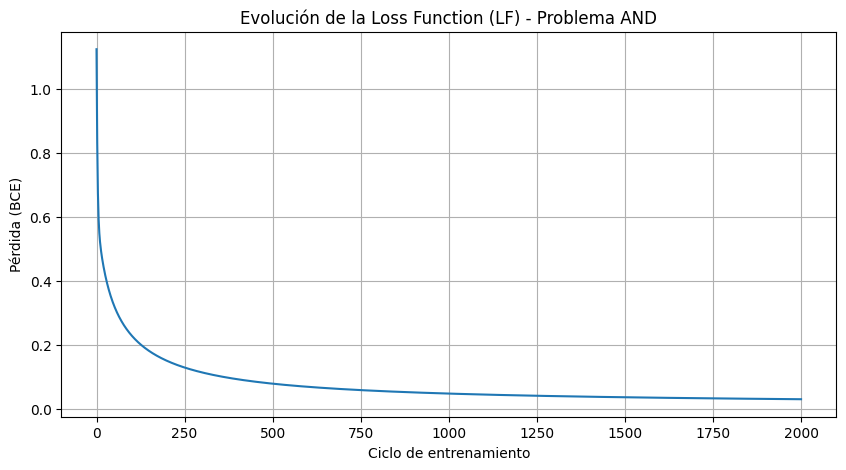

--- Valores Finales de los Parámetros ---
w1: 6.2081, w2: 6.2081, b: -9.4886

--- Verificación de Resultados Finales ---
Input: [0 0] | Target: 0 | Predicción: 0.0001
Input: [0 1] | Target: 0 | Predicción: 0.0362
Input: [1 0] | Target: 0 | Predicción: 0.0362
Input: [1 1] | Target: 1 | Predicción: 0.9492


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Funciones base (Sigmoidea y su derivada, Loss y su derivada)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy_loss(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15) # Evitar log(0)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 2. Datos de entrenamiento (Lógica AND)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])

# 3. Inicialización de parámetros al azar
np.random.seed(42) # Para reproducibilidad
input_size = 2
weights = np.random.rand(input_size)
bias = np.random.rand(1)

# 4. Hiperparámetros
lr_inicial = 0.5    # Learning Rate
epochs = 2000       # Ciclos de entrenamiento
loss_history = []

# 5. Ciclo de Entrenamiento
for epoch in range(epochs):
    dw_batch = np.zeros(input_size)
    db_batch = 0
    total_loss = 0
    
    # Opcional: LR decreciente (como sugiere el consejo del TP)
    lr = lr_inicial / (1 + 0.001 * epoch)
    
    # Forward y Backward para cada ejemplo (acumulando para el batch)
    for i in range(len(X)):
        inputs = X[i]
        y_true = Y[i]
        
        # Forward pass
        z = np.dot(weights, inputs) + bias
        y_pred = sigmoid(z)
        
        # Calcular Loss
        total_loss += binary_cross_entropy_loss(y_pred, y_true)
        
        # Gradientes (Derivada simplificada de BCE + Sigmoidea: y_pred - y_true)
        error_delta = y_pred - y_true
        dw_batch += error_delta * inputs
        db_batch += error_delta
    
    # Actualización de parámetros usando el promedio del batch
    weights -= lr * (dw_batch / len(X))
    bias -= lr * (db_batch / len(X))
    
    # Guardar pérdida promedio para graficar
    loss_history.append(total_loss / len(X))

# 6. Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title("Evolución de la Loss Function (LF) - Problema AND")
plt.xlabel("Ciclo de entrenamiento")
plt.ylabel("Pérdida (BCE)")
plt.grid(True)
plt.show()

print("--- Valores Finales de los Parámetros ---")
print(f"w1: {weights[0]:.4f}, w2: {weights[1]:.4f}, b: {bias[0]:.4f}")

print("\n--- Verificación de Resultados Finales ---")
for i in range(len(X)):
    z = np.dot(weights, X[i]) + bias
    pred = sigmoid(z)
    print(f"Input: {X[i]} | Target: {Y[i]} | Predicción: {pred[0]:.4f}")

#b) Evaluacion de LF con ReLU

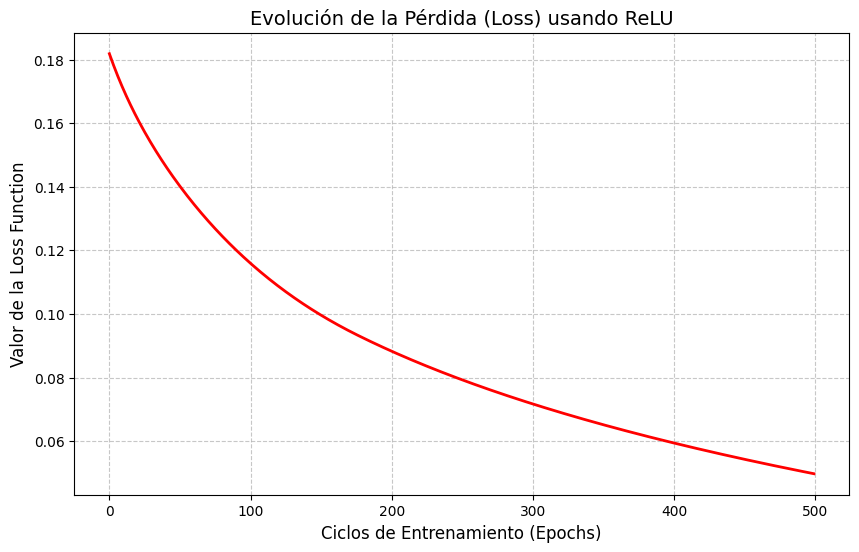

Resultados finales con ReLU:
Input: [0 0] | Predicción: 0.0000
Input: [0 1] | Predicción: 0.2458
Input: [1 0] | Predicción: 0.1988
Input: [1 1] | Predicción: 0.6857


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Funciones para ReLU
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Para ReLU, usamos el Error Cuadrático Medio (MSE) como Loss Function
def mse_loss(y_pred, y_true):
    return (y_pred - y_true) ** 2

# 2. Datos del AND
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])

# 3. Inicialización azarosa
np.random.seed(42)
weights = np.random.uniform(-0.5, 0.5, 2)
bias = np.random.uniform(-0.5, 0.5, 1)

# 4. Hiperparámetros
lr = 0.01
epochs = 500
loss_history = []

# 5. Ciclo de entrenamiento (Batch)
for epoch in range(epochs):
    dw_batch = np.zeros(2)
    db_batch = 0
    total_loss = 0
    
    for i in range(len(X)):
        # Forward Pass
        z = np.dot(X[i], weights) + bias
        y_pred = relu(z)
        
        # Cálculo de pérdida
        loss = mse_loss(y_pred, Y[i])
        total_loss += loss
        
        # Gradientes (Regla de la cadena)
        # dL/dy = 2*(y_pred - y_true)
        # dy/dz = relu_derivative(z)
        error_delta = 2 * (y_pred - Y[i]) * relu_derivative(z)
        
        dw_batch += error_delta * X[i]
        db_batch += error_delta
        
    # Actualización de parámetros (Promedio del batch)
    weights -= lr * (dw_batch / len(X))
    bias -= lr * (db_batch / len(X))
    
    loss_history.append(total_loss / len(X))

# --- GENERACIÓN DEL GRÁFICO ---
plt.figure(figsize=(10, 6))
plt.plot(loss_history, color='red', linewidth=2)
plt.title("Evolución de la Pérdida (Loss) usando ReLU", fontsize=14)
plt.xlabel("Ciclos de Entrenamiento (Epochs)", fontsize=12)
plt.ylabel("Valor de la Loss Function", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Verificación final
print("Resultados finales con ReLU:")
for i in range(len(X)):
    z = np.dot(X[i], weights) + bias
    print(f"Input: {X[i]} | Predicción: {relu(z)[0]:.4f}")

Las predicciones utilizando ReLU son mucho mas bajas que las anteriores para el caso de la funcion AND la que es verdadera con las entradas [1,1] es bastante baja. 

**Funcion OR utilizando Sigmoidea**

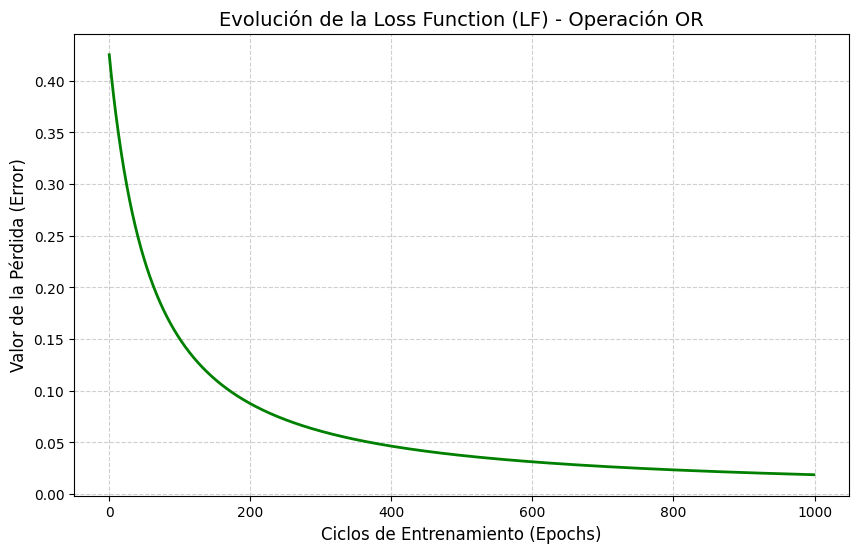

Pesos finales: [7.24826392 7.25030631], Bias final: [-3.15211478]

Predicciones finales:
Entrada: [0 0] | Predicción: 0.0410
Entrada: [0 1] | Predicción: 0.9837
Entrada: [1 0] | Predicción: 0.9836
Entrada: [1 1] | Predicción: 1.0000


In [35]:

# 1. Funciones base (Sigmoidea y Loss)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy_loss(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15) # Para evitar errores matemáticos
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 2. Datos para la función lógica OR
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 1, 1, 1]) 

# 3. Inicialización azarosa de parámetros
np.random.seed(42)
weights = np.random.rand(2)
bias = np.random.rand(1)

# 4. Hiperparámetros
lr = 0.5
epochs = 1000
loss_history = [] # Lista para guardar el error de cada ciclo

# 5. Ciclo de entrenamiento (Batch Gradient Descent)
for epoch in range(epochs):
    dw_batch = np.zeros(2)
    db_batch = 0
    total_loss = 0
    
    for i in range(len(X)):
        # Forward pass
        z = np.dot(X[i], weights) + bias
        y_pred = sigmoid(z)
        
        # Calcular pérdida
        total_loss += binary_cross_entropy_loss(y_pred, Y[i])
        
        # Calcular gradientes (derivada simplificada de BCE + Sigmoidea)
        error_delta = y_pred - Y[i]
        dw_batch += error_delta * X[i]
        db_batch += error_delta
        
    # Actualización de parámetros usando el promedio del batch
    weights -= lr * (dw_batch / len(X))
    bias -= lr * (db_batch / len(X))
    
    # Guardamos la pérdida promedio de este ciclo para la gráfica
    loss_history.append(total_loss / len(X))

# --- CÓDIGO PARA LA GRÁFICA ---
plt.figure(figsize=(10, 6))
plt.plot(loss_history, color='green', linewidth=2)
plt.title("Evolución de la Loss Function (LF) - Operación OR", fontsize=14)
plt.xlabel("Ciclos de Entrenamiento (Epochs)", fontsize=12)
plt.ylabel("Valor de la Pérdida (Error)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Verificación final de la tabla de verdad
print(f"Pesos finales: {weights}, Bias final: {bias}")
print("\nPredicciones finales:")
for i in range(len(X)):
    z = np.dot(X[i], weights) + bias
    print(f"Entrada: {X[i]} | Predicción: {sigmoid(z)[0]:.4f}")

El calculo es bastante certero puesto que la unica salida [0.0] es False, entonces la prediccion en este caso es baja, y las otras entradas se aproximan a 1.